In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 100
S = 7
R = 10000

In [3]:
np.random.seed(2026)

In [4]:
sobres_totales = []
repetidas_totales = []

In [5]:
for simulacion in range(R):
    album = np.zeros(N, dtype = bool)
    sobres = 0
    repetidas = 0
    distintas = 0
    while distintas < N:
        sobres += 1
        sobre = np.random.choice(
            np.arange(N),
            size = S,
            replace = False
        )
        for estampa in sobre:
            if album[estampa]:
                repetidas += 1
            else:
                album[estampa] = True
                distintas += 1
    sobres_totales.append(sobres)
    repetidas_totales.append(repetidas)

In [6]:
media_sobres = np.mean(sobres_totales)
desv_sobres = np.std(sobres_totales)
media_rep = np.mean(repetidas_totales)
desv_rep = np.std(repetidas_totales)
prob_30 = np.mean(np.array(sobres_totales) > 30)

In [7]:
print('Resultados')
print('Media sobres:', round(media_sobres, 2))
print('Desviacion sobres:', round(desv_rep, 2))
print('Media repetidas:', round(media_rep, 2))
print('Desviacion repetidas:', round(desv_rep, 2))
print('P(necesitar > 30 sobres):', round(prob_30, 4))

Resultados
Media sobres: 72.25
Desviacion sobres: 122.3
Media repetidas: 405.72
Desviacion repetidas: 122.3
P(necesitar > 30 sobres): 1.0


In [8]:
minimo_teorico = np.ceil(N/S)
print('Minimo teorico:', minimo_teorico)

Minimo teorico: 15.0


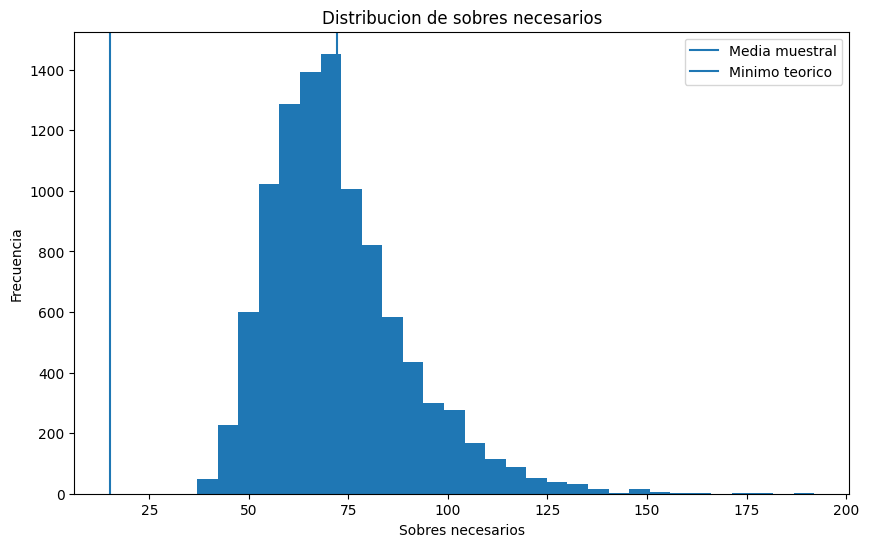

In [9]:
plt.figure(figsize = (10, 6))
plt.hist(
    sobres_totales,
    bins = 30
)
plt.axvline(
    media_sobres,
    label = 'Media muestral'
)
plt.axvline(
    minimo_teorico,
    label = 'Minimo teorico'
)
plt.xlabel('Sobres necesarios')
plt.ylabel('Frecuencia')
plt.title('Distribucion de sobres necesarios')
plt.legend()
plt.show()

Pregunta de analisis 1:
El numero minimo teorico ocurre cuando todas las estampas obtenidas son distintas. Como el album tiene 100 estampas y 7 estampas por sobre el minimos de sobres necesarios es (100/7) = 15, por lo que el minimo teorico es 15 sobres. Este caso implicaria que no aparezca ninguna estampa repetida durante todo el proceso, lo cual es extremadamente improbable. En las simulaciones realizadas no se espera observar este caso debido a la aleatoriedad y a la alta probabilidad de repetion.

Pregunta de analisis 2: La teoría del coleccionista establece:
E[T]=(N/S)H donde: H=ln(N)+γ con: γ = 0.5772 Para N=100: H(100)=ln(100)+0.5772=5.1824 Sustituyendo: E[T]=(100/7)(5.1824)=74.03 La simulacion produjo una media de 72.25 la diferencia entre el valor teorico y el valor simulado es pequeña: 74.03-72.25=1.78 Por lo tanto, los resultados experimentales son consistentes con la teoría.

Pregunta de analisis 3:
El numero esperado de estampas repetidas puede calcularse usando: Repetidas=7(T)-100 Sustituyendo el valor esperado: 7(74.03)-100=418.21 La media obtenida en la simulacion fue: 405.72 La diferencia observada es 12.49 El resultado obtenido experimentalmente es cercano al valor esperado teorico

Pregunta de analisis 4: La desviación estándar obtenida fue relativamente grande respecto a la media, lo cual indica que existe una variabilidad considerable en el número de sobres necesarios para completar el álbum. Esto ocurre porque las primeras estampas se consiguen fácilmente, pero las últimas estampas faltantes se vuelven cada vez más difíciles de obtener. Algunas simulaciones completan el álbum rápidamente mientras otras requieren muchos sobres adicionales. Este comportamiento genera una distribución sesgada con una cola larga hacia la derecha, provocando una desviación estándar elevada.

In [11]:
print("Mediana:", np.median(sobres_totales))

Mediana: 69.0
